# Inside the Eirenesphere: The Interplay of Porosity, Heat Flux and Mineralogy in Exoplanetary Aquable and Habitable Layers

## [Santiago A. Orjuela](mailto:santiagoa.orjuela@udea.edu.co) and [Jorge I. Zuluaga](mailto:jorge.zuluaga@udea.edu.co)

## Thermal Structure and Mineralogical Composition

This notebook computes 1D planetary geotherms and internal structure profiles (temperature, pressure, porosity) across a range of planetary masses and surface heat fluxes. It also implements the parametric mineralogical model used throughout the HAB-3D framework to investigate how lithospheric composition — felsic fraction, Fe/Mg ratio, and hydration state — controls the thickness of subsurface aquable and habitable layers.

### Libraries

**IMPORTANT**: Before running please install requirements with `pip install -r requirements.txt`. This notebook should be ran in the same directory as `geotherm_calculator.py`, `habitability_calculator.py`, `planetary_grid_reader.py`. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geotherm_calculator as gc
import habitability_calculator as hc

from astropy import constants as const

### Constants

In [3]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.386e9 #Terrestrial Oceans volume in km3
G = const.G.value # Gravitational constant (m3 kg-1 s-2)
g_earth = const.g0.value # Surface gravity Earth (m s-2)

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 

Lsun = const.L_sun.value # Solar luminosity (W)
au = const.au.value # Astronomical Unit (m)

hc_earth = 35  #km
hr_earth = np.array([0.25, 0.35])*hc_earth 


### Plots Config

In [37]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
})

### HC Composition

In [29]:
comp_earth = gc.COMPOSITION_DEFAULT #Hasterok & Chapman
mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(mineral_objects=mineral_objects, composition=comp_earth)

## Thermal structure and internal profiles

### Different Surface Heat Flux 

In [36]:
qss = np.linspace(20, 200, 10) * 1e-3 
z_max = 100e3
dz = 100.0
T_surface = 288.0
h_r = gc.scale_hr(M_planet=Me, R_planet=Re)
geos = np.zeros((len(qss)), dtype=object)

for i, q in enumerate(qss):
    A_surf = gc.A0(q_surface=q, D=h_r)
    df = gc.calculate_geotherm(
        rocks=rocks,
        q_s=q,
        z_max=z_max,
        dz=dz,
        R_planet=Re,
        M_total=Me,
        composition=gc.COMPOSITION_DEFAULT,
        boundaries=gc.scale_layer_boundaries(Re),
        T_top=T_surface,
        A_surface=A_surf,
        h_r=h_r,
        DEBUG=False
    )
    
    
    geos[i] = df


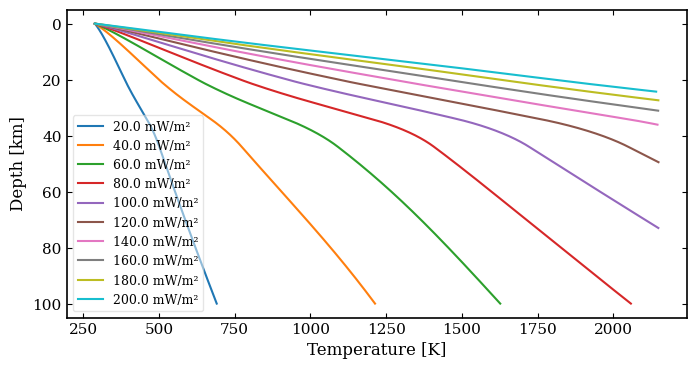

In [38]:
plt.figure(figsize=(8, 4), facecolor='white')

for q in range(len(qss)):
    geo = geos[q]
    plt.plot(geo['T_K'], geo['depth_m']/km, label=f'{qss[q]*1000:.1f} mW/m²')


plt.gca().invert_yaxis()
plt.xlabel('Temperature [K]')
plt.ylabel('Depth [km]')
plt.legend(loc='lower left', framealpha=0.5)
plt.show()
    

### Different Masses

In [ ]:
Masses1 = np.array([0.1, 0.5, 1, 2, 5, 10]) * Me
Masses2 = np.linspace(0.1, 10, 20) * Me
qs = 65e-3
z_max = 20e3
T_surf = hc.T_eq(1)

Masses = Masses2
geos = np.zeros((len(Masses)), dtype=object)
water_thickness = np.zeros(len(Masses))
Hab_thickness = np.zeros(len(Masses))
water_depth_start = np.zeros(len(Masses))
habitable_depth_start = np.zeros(len(Masses))

for m in range(len(Masses)):
    radius = gc.mass_to_radius(M_planet=Masses[m])
    Ptop = gc.surface_pressure(M_planet = Masses[m])
    hr = gc.scale_hr(M_planet=Masses[m], R_planet=radius)
    A_surf = gc.A0(q_surface=qs, D=hr)
    
    geo = gc.calculate_geotherm(rocks = rocks,
                         q_s = qs,
                         z_max = z_max,
                         dz = 100.0,
                         R_planet = radius,
                         M_total = Masses[m],
                         boundaries = gc.scale_layer_boundaries(radius),
                         h_r = hr,
                         P_top = Ptop,
                         A_surface = A_surf
    )
    geos[m] = geo
    
    #Capa Aguable y Habitable
    liq_layer = hc.find_liquid_zone(geo, information=False)
    hab_layer = hc.find_habitable_zone(liq_layer['indices'],
                                       geo,
                                       phi_min=1e-3,
                                       information=True)
    
    if liq_layer['indices'] is not None:
        water_thickness[m] = (liq_layer['liquid_zone'][-1] - liq_layer['liquid_zone'][0]) / km
        water_depth_start[m] = (liq_layer['liquid_zone'][0]) / km
        
    if hab_layer['indices'] is not None:
        Hab_thickness[m] = (hab_layer['habitable_zone'][-1] - hab_layer['habitable_zone'][0]) / km
        habitable_depth_start[m] = (hab_layer['habitable_zone'][0]) / km
    

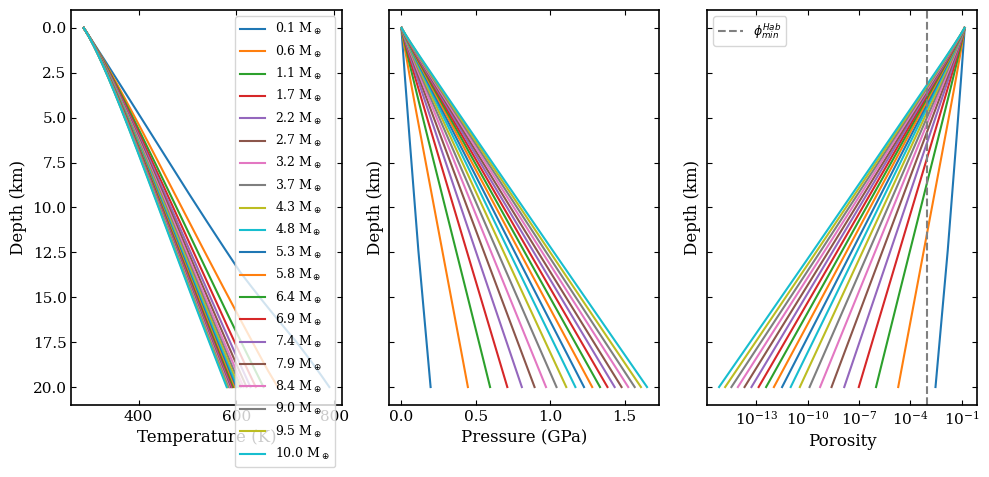

In [35]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
})

#Subplot de T(z), P(z) y phi(z) para cada masa
from matplotlib.pyplot import gca


fig, axs = plt.subplots(1, 3, figsize=(10, 5),sharey=True, facecolor='white')
for m in range(len(Masses)):
    geo = geos[m]
    axs[0].plot(geo['T_K'], geo['depth_m']/km, label=f'{Masses[m]/Me:.1f} M$_\oplus$')
    axs[0].set_xlabel('Temperature (K)')
    axs[0].set_ylabel('Depth (km)')
    axs[0].legend()
    
    axs[1].plot(geo['P_Pa']/Gpa, geo['depth_m']/km)
    axs[1].set_xlabel('Pressure (GPa)')
    axs[1].set_ylabel('Depth (km)')
    
    axs[2].plot(geo['phi'], geo['depth_m']/km)
    axs[2].semilogx()
    axs[2].set_xlabel('Porosity')
    axs[2].set_ylabel('Depth (km)')
axs[2].axvline(1e-3, ls='--', color='gray', label='$\\phi_{min}^{Hab}$')
axs[2].legend(loc='upper left')

gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Layer Thickness

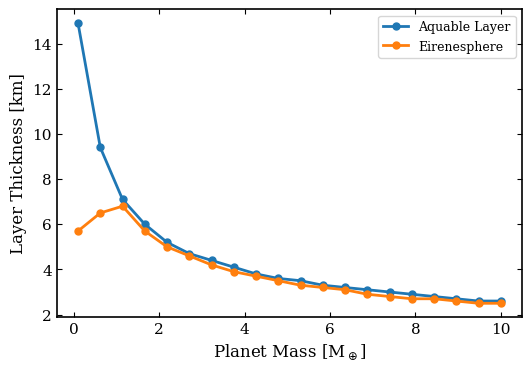

In [41]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
ax.plot(Masses/Me, water_thickness, marker='o', lw=2, markersize=5, label='Aquable Layer', zorder=3)
ax.plot(Masses/Me, Hab_thickness, marker='o', lw=2, markersize=5,  label='Eirenesphere', zorder=3)
ax.set_xlabel('Planet Mass [M$_\oplus$]')
ax.set_ylabel('Layer Thickness [km]')
ax.legend()
plt.show()

In [43]:
if Hab_thickness.max() > 0:
        max_hab_idx = np.argmax(Hab_thickness)
        print(f"\n Eirenesphere Max Layer Thickness:")
        print(f"   Thickness: {Hab_thickness[max_hab_idx]:.2f} km")
        print(f"   Start Depth: {habitable_depth_start[max_hab_idx]:.2f} km")
        print(f"   Planet Mass: {Masses[max_hab_idx]/Me:.1f} $M_\oplus$")
    
if water_thickness.max() > 0:
        max_water_idx = np.argmax(water_thickness)
        print(f"\n Max Aquability Layer Thickness:")
        print(f"   Thickness: {water_thickness[max_water_idx]:.2f} km")
        print(f"   Start Depth: {water_depth_start[max_water_idx]:.2f} km")
        print(f"   Planet Mass: {Masses[max_water_idx]/Me:.1f} $M_\oplus$")
    
  


 Eirenesphere Max Layer Thickness:
   Thickness: 6.80 km
   Start Depth: 0.00 km
   Planet Mass: 1.1 $M_\oplus$

 Max Aquability Layer Thickness:
   Thickness: 14.90 km
   Start Depth: 0.00 km
   Planet Mass: 0.1 $M_\oplus$


## Mineralogic Composition

In [44]:
def layer_comp(f_felsic_capa, hidr_capa, X_Mg, X_Fe, es_manto=False):
    """
    Calculate the mineral composition for a single geological layer.
    
    Parameters:
    ----------
    f_felsic_capa : float (Specific felsic fraction for this layer)
    hidr_capa     : float (Specific hydration level for this layer)
    X_Mg          : float (Molar fraction of Magnesium)
    X_Fe          : float (Molar fraction of Iron)
    es_manto      : bool  (Forces a peridotite/garnet composition if True)
    """
    
    # 1. Estructural base
    if es_manto:
        Quartz_base = 0.0
        Orthoclase_base = 0.0
        Albite_base = 0.0
        Anorthite_base = 0.0
        piroxeno_total = 35.0
        olivino_total = 60.0
    else:
        # Composition based on felsic fraction
        Quartz_base     = 30.0 * f_felsic_capa
        Orthoclase_base = 15.0 * f_felsic_capa
        Albite_base     = 20.0 * f_felsic_capa + 10.0 * (1 - f_felsic_capa)
        Anorthite_base  = 10.0 * f_felsic_capa + 25.0 * (1 - f_felsic_capa)
        piroxeno_total  = 40.0 * (1 - f_felsic_capa)
        olivino_total   = 20.0 * (1 - f_felsic_capa)

    # 2. Partitioning of Fe/Mg in the ferromagnesian minerals
    Forsterite = olivino_total * X_Mg
    Fayalite   = olivino_total * X_Fe

    px_ortho = piroxeno_total * 0.7
    px_clino = piroxeno_total * 0.3
    Enstatite    = px_ortho * X_Mg
    Ferrosillite = px_ortho * X_Fe
    Diopside     = px_clino * X_Mg
    Hedenbergite = px_clino * X_Fe

    # 3. Hydration
    Hornblende = 0.0
    Phlogopite = 0.0

    if hidr_capa > 0 and not es_manto:
        transferencia = hidr_capa * 0.4
        px_total = Enstatite + Ferrosillite + Diopside + Hedenbergite
        delta_px = px_total * transferencia

        if px_total > 0:
            factor = (px_total - delta_px) / px_total
            Enstatite    *= factor
            Ferrosillite *= factor
            Diopside     *= factor
            Hedenbergite *= factor

        Hornblende += delta_px

        delta_an = Anorthite_base * (transferencia * 0.3)
        Anorthite_base -= delta_an
        Hornblende += delta_an

        delta_k = Orthoclase_base * hidr_capa * 0.5
        Orthoclase_base -= delta_k
        Phlogopite += delta_k

    # 4. Assemble base dictionary
    comp_bruta = {
        "Quartz": Quartz_base,
        "Orthoclase": Orthoclase_base,
        "Albite": Albite_base,
        "Anorthite": Anorthite_base,
        "Forsterite": Forsterite,
        "Fayalite": Fayalite,
        "Enstatite": Enstatite,
        "Ferrosillite": Ferrosillite,
        "Diopside": Diopside,
        "Hedenbergite": Hedenbergite,
        "Hornblende": Hornblende,
        "Phlogopite": Phlogopite
    }
    
    # Add garnet component for the mantle if specified
    if es_manto:
        comp_bruta["Pyrope"] = 5.0 * X_Mg
        comp_bruta["Almandine"] = 5.0 * X_Fe

    # 5. Normalization
    comp_bruta = {k: max(0, v) for k, v in comp_bruta.items()}
    total = sum(comp_bruta.values())
    
    if total == 0:
        raise ValueError("Composition degenerate in the calculated layer.")

        
    return {mineral: (val / total * 100) for mineral, val in comp_bruta.items() if val > 0}


def crust_comp(f_felsic=0.5, Fe_Mg=0.1, hidratacion=0.0):
    """
    Generates a complete dictionary (upper, middle, lower, mantle) 
    parameterized according to the general geochemistry of the exoplanet.

    Parameters:
    ----------
    f_felsic : float (Felsic fraction at the surface)
    Fe_Mg : float (Global molar ratio Fe/Mg of the planet)
    hidratacion : float (Degree of hydration at the surface)
    """

    # The partitioning of Fe/Mg is global for the entire planet
    X_Fe = Fe_Mg / (1.0 + Fe_Mg)
    X_Mg = 1.0 - X_Fe

    # 1. UPPER CRUST: Uses the intact surface parameters
    upper = layer_comp(f_felsic, hidratacion, X_Mg, X_Fe)
    
    # 2. MIDDLE CRUST: Transition (half of the felsic and water influence)
    middle = layer_comp(f_felsic * 0.5, hidratacion * 0.5, X_Mg, X_Fe)
    
    # 3. LOWER CRUST: Almost completely mafic (Gabbro) and very dry
    lower = layer_comp(f_felsic * 0.1, hidratacion * 0.1, X_Mg, X_Fe)
    
    # 4. MANTLE: Strictly ultramafic (Peridotite), dry, without feldspars
    mantle = layer_comp(0.0, 0.0, X_Mg, X_Fe, es_manto=True)

    return {
        "upper": upper,
        "middle": middle,
        "lower": lower,
        "mantle": mantle
    }

In [ ]:
mineral_objects = gc.get_mineral_objects()

f_felsic_vals = np.linspace(0.0, 1.0, 20)  
Fe_Mg_vals = np.linspace(0.0, 0.5, 20)     

h_vals = np.array([0.0, 0.30])

In [ ]:
geos = np.zeros((len(f_felsic_vals), len(Fe_Mg_vals), len(h_vals)), dtype=object)


for i in range(len(f_felsic_vals)):
    for j in range(len(Fe_Mg_vals)):
        for k in range(len(h_vals)):
            comp = crust_comp(f_felsic=f_felsic_vals[i], Fe_Mg=Fe_Mg_vals[j], hidratacion=h_vals[k])
            print(f"f_felsic={f_felsic_vals[i]:.2f}, Fe/Mg={Fe_Mg_vals[j]:.2f}, hidratacion={h_vals[k]:.2f}")
            
            rock = gc.prepare_rocks_dict(composition=comp, 
                           mineral_objects=mineral_objects)
            
            geo = gc.calculate_geotherm(rocks = rock,
                                        composition=comp,
                                        q_s = 65e-3,
                                        z_max=15*km,
                                        dz = 100,
                                        R_planet=Re,
                                        M_total=Me,
                                        boundaries = gc.scale_layer_boundaries(Re),
                                        )
            geos[i, j, k] = geo
            
            
np.save("geos_exoplanet.npy", geos)

f_felsic=0.00, Fe/Mg=0.00, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.00, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.03, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.03, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.05, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.05, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.08, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.08, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.11, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.11, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.13, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.13, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.16, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.16, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.18, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.18, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.21, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.21, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.24, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.24, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.26, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.26, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.29, hidra

In [ ]:
geos = np.load("geos.npy", allow_pickle=True)
mapa_seco = np.zeros((len(f_felsic_vals), len(Fe_Mg_vals)))
mapa_hidr = np.zeros((len(f_felsic_vals), len(Fe_Mg_vals)))

for i in range(geos.shape[0]):
    for j in range(geos.shape[1]):
        for k in range(geos.shape[2]):
            geo = geos[i, j, k]
            liq = hc.find_liquid_zone(geo)
            hab = hc.find_habitable_zone(liq['indices'], geo, P_bio_max=200e6, T_bio_max=423.0)
            
            # Calcular espesor en km
            if len(hab['indices']) > 0:
                thick_hab = (hab['habitable_zone'][-1] - hab['habitable_zone'][0]) / 1000.0
            else:
                thick_hab = 0.0

            # Asignar el espesor a la matriz correspondiente según la hidratación
            if h_vals[k] == 0.0:
                mapa_seco[i, j] = thick_hab
            else:
                mapa_hidr[i, j] = thick_hab

In [ ]:
vmin = min(np.min(mapa_seco), np.min(mapa_hidr))
vmax = max(np.max(mapa_seco), np.max(mapa_hidr))
cmap = 'YlOrRd' 

X, Y = np.meshgrid(Fe_Mg_vals, f_felsic_vals)

def plot_heatmap(ax, data, title):

    # Campo continuo
    im = ax.pcolormesh(
        X, Y, data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading='auto'
    )

    # Contornos (isolineas)
    cs = ax.contour(
        X, Y, data,
        colors='black',
        linewidths=0.8,
        levels=10,
        alpha=0.7
    )

    ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

    ax.set_title(title)
    ax.set_xlabel('Molar ratio Fe/Mg')

    ax.set_xticks(np.linspace(min(Fe_Mg_vals), max(Fe_Mg_vals), 5))
    ax.set_yticks(np.linspace(min(f_felsic_vals), max(f_felsic_vals), 5))

    ax.tick_params(direction='in', top=True, right=True)

    return im

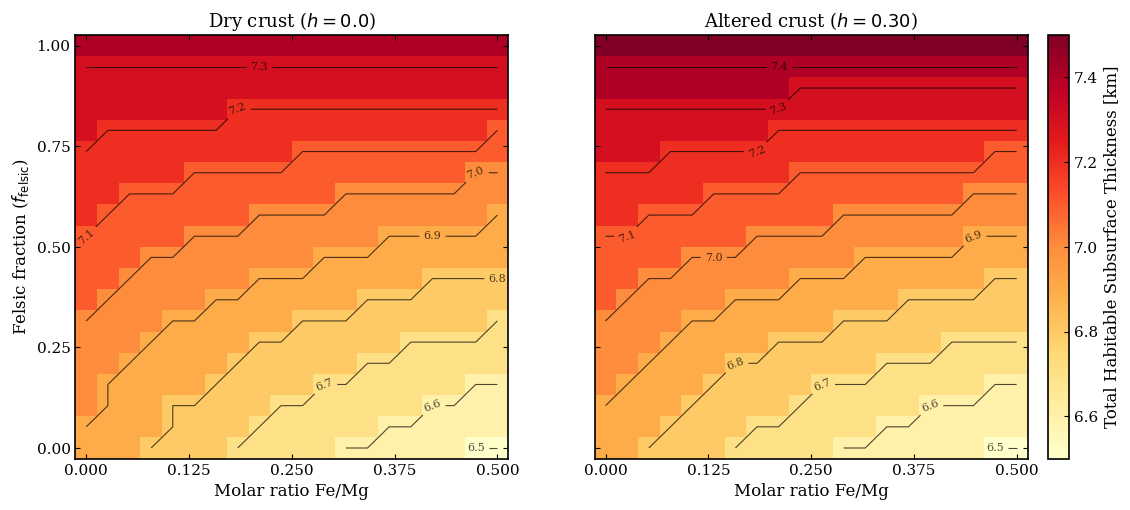

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

im1 = plot_heatmap(
    axes[0],
    mapa_seco,
    r'Dry crust ($h = 0.0$)',
)
axes[0].set_ylabel(r'Felsic fraction ($f_{\mathrm{felsic}}$)')

im2 = plot_heatmap(
    axes[1],
    mapa_hidr,
    r'Altered crust ($h = 0.30$)',
)

cbar = fig.colorbar(im2, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label('Total Habitable Subsurface Thickness [km]')


for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)




plt.show()

In [52]:
#guardar el dataframe geos en un archivo .npy
np.save('geos.npy', geos)